# 01 · Data Cleaning — Restaurants de Niamey
**Projet :** Analyse du marché de la restauration à Niamey, Niger  
**Source :** Export Google Maps (CSV)  
**Objectif :** Produire un dataset propre, enrichi et documenté pour l'EDA et la modélisation

---
## Checklist de nettoyage
- [ ] Chargement & inspection du schéma
- [ ] Analyse des valeurs manquantes
- [ ] Détection des doublons
- [ ] Nettoyage colonne par colonne
- [ ] Feature engineering (score bayésien, tiers de fiabilité, flags)
- [ ] Rapport qualité final
- [ ] Export `processed/restaurants_clean.csv`


## 0 · Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

# Paths
RAW_PATH  = Path("../data/raw/All_Niamey_Restaurants.csv")
PROC_PATH = Path("../data/processed/restaurants_clean.csv")
PROC_PATH.parent.mkdir(parents=True, exist_ok=True)
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)

print("✅ Imports OK")

✅ Imports OK


In [2]:
# Téléchargement neutralisé : le CSV source est déjà présent dans data/raw/.
# (À l'origine, cette cellule téléchargeait le dataset depuis une Google Sheet publique.)
print(f"✅ Dataset source déjà en place : {RAW_PATH} "
      f"({RAW_PATH.stat().st_size / 1024:.1f} Ko)" if RAW_PATH.exists()
      else f"❌ Fichier introuvable : {RAW_PATH}")

✅ Dataset source déjà en place : ../data/raw/All_Niamey_Restaurants.csv (94.6 Ko)


## 1 · Chargement des données
Le CSV présente une colonne `Column` résiduelle (artefact d'export) et un encodage
potentiellement mixte — on force `utf-8` avec fallback `latin-1`.


In [3]:
print(f"Files in '{RAW_PATH.parent}' directory:")
for item in RAW_PATH.parent.iterdir():
    print(f"- {item.name}")

Files in '../data/raw' directory:
- All_Niamey_Restaurants.csv


In [4]:
def load_csv(path: Path) -> pd.DataFrame:
    """Charge le CSV avec détection automatique de l'encodage."""
    for enc in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"Encodage utilisé : {enc}")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError("Impossible de lire le fichier.")

df_raw = load_csv(RAW_PATH)

print(f"Shape brut : {df_raw.shape}")
df_raw.head(3)


Encodage utilisé : utf-8
Shape brut : (490, 12)


,title,totalScore,reviewsCount,street,city,state,countryCode,website,phone,categoryName,url,Column
0,Amandine,3.9,1408.0,G476+RX4,Niamey,NaN,NE,https://www.facebook.com/restoamandine?mibextid=kFxxJD,+227 90 19 49 08,Restaurant,https://www.google.com/maps/search/?api=1&query=Amandine...,NaN
1,Bab Salam Maurice Delens,3.9,1351.0,G3MW+WR4,Niamey,NaN,NE,NaN,+227 91 95 47 48,Restauration rapide,https://www.google.com/maps/search/?api=1&query=Bab%20Sa...,NaN
2,Rawda,3.8,883.0,"G4H4+8R9, Bd du Zarmaganda",Niamey,NaN,NE,NaN,+227 88 66 80 20,Restaurant,https://www.google.com/maps/search/?api=1&query=Rawda&qu...,NaN


In [5]:
# Aperçu du schéma
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         490 non-null    str    
 1   totalScore    373 non-null    float64
 2   reviewsCount  372 non-null    float64
 3   street        432 non-null    str    
 4   city          474 non-null    str    
 5   state         0 non-null      float64
 6   countryCode   490 non-null    str    
 7   website       26 non-null     str    
 8   phone         317 non-null    str    
 9   categoryName  489 non-null    str    
 10  url           489 non-null    str    
 11  Column        1 non-null      str    
dtypes: float64(3), str(9)
memory usage: 46.1 KB


## 2 · Audit du schéma
Renommage des colonnes pour cohérence snake_case, suppression de la colonne
parasite `Column`.


In [6]:
# Colonnes attendues dans le CSV source
RENAME_MAP = {
    "title":        "name",
    "totalScore":   "score_raw",
    "reviewsCount": "reviews_count",
    "street":       "street",
    "city":         "city",
    "state":        "state",
    "countryCode":  "country_code",
    "website":      "website",
    "phone":        "phone",
    "categoryName": "category",
    "url":          "maps_url",
}

df = df_raw.copy()

# Supprimer la colonne artefact si présente
if "Column" in df.columns:
    df.drop(columns=["Column"], inplace=True)
    print("Colonne 'Column' supprimée.")

# Renommer
df.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df.columns}, inplace=True)

print(f"\nColonnes finales ({len(df.columns)}) :")
print(df.columns.tolist())


Colonne 'Column' supprimée.

Colonnes finales (11) :
['name', 'score_raw', 'reviews_count', 'street', 'city', 'state', 'country_code', 'website', 'phone', 'category', 'maps_url']


## 3 · Analyse des valeurs manquantes
Règle : on ne supprime pas de lignes sur les champs optionnels (website, phone).
On supprime uniquement si `name` est manquant — les restaurants sans nom sont inexploitables.


In [7]:
# Vue quantitative
missing = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={"index": "champ", 0: "nb_manquants"})
)
missing["pct"] = (missing["nb_manquants"] / len(df) * 100).round(1)
missing = missing[missing["nb_manquants"] > 0].sort_values("pct", ascending=False)
print(missing.to_string(index=False))


        champ  nb_manquants   pct
        state           490 100.0
      website           464  94.7
        phone           173  35.3
reviews_count           118  24.1
    score_raw           117  23.9
       street            58  11.8
         city            16   3.3
     category             1   0.2
     maps_url             1   0.2


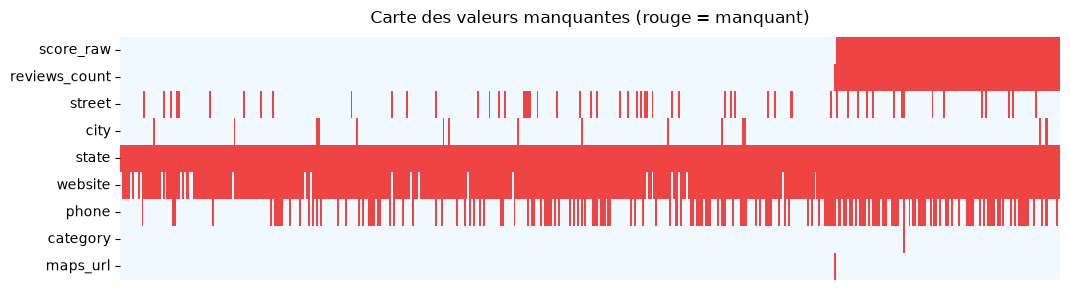

Lignes avec au moins 1 NaN : 490 / 490


In [8]:
# Heatmap des valeurs manquantes (colonnes avec au moins 1 NaN)
cols_with_na = df.columns[df.isnull().any()].tolist()

fig, ax = plt.subplots(figsize=(len(cols_with_na) * 1.2, 3))
sns.heatmap(
    df[cols_with_na].isnull().T,
    cbar=False, cmap=["#F0F9FF", "#EF4444"],
    yticklabels=cols_with_na, xticklabels=False, ax=ax
)
ax.set_title("Carte des valeurs manquantes (rouge = manquant)", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("../data/processed/missing_heatmap.png", dpi=120)
plt.show()
print(f"Lignes avec au moins 1 NaN : {df.isnull().any(axis=1).sum()} / {len(df)}")


In [9]:
# Supprimer les entrées sans nom (inexploitables)
before = len(df)
df.dropna(subset=["name"], inplace=True)
print(f"Lignes supprimées (name manquant) : {before - len(df)}")
print(f"Dataset restant : {len(df)} lignes")


Lignes supprimées (name manquant) : 0
Dataset restant : 490 lignes


## 4 · Détection des doublons
On cherche les doublons sur `name` + `maps_url` (identifiant Google Maps).
Un même nom peut légitimement apparaître dans des quartiers différents
(ex. chaînes) — on conserve, on flag.


In [10]:
# Doublons exacts (même URL Google Maps)
exact_dupes = df[df.duplicated(subset=["maps_url"], keep=False)]
print(f"Doublons exacts sur maps_url : {len(exact_dupes)}")
if len(exact_dupes):
    print(exact_dupes[["name", "street", "maps_url"]].to_string(index=False))

# Déduplication : on garde la ligne avec le plus d'avis
df.sort_values("reviews_count", ascending=False, inplace=True)
df.drop_duplicates(subset=["maps_url"], keep="first", inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nDataset après déduplication : {len(df)} lignes")


Doublons exacts sur maps_url : 0

Dataset après déduplication : 490 lignes


In [11]:
# Doublons de noms (chaînes / branches)
name_counts = df["name"].value_counts()
chain_names = name_counts[name_counts > 1]
print(f"Noms apparaissant plusieurs fois ({len(chain_names)}) :")
print(chain_counts := df[df["name"].isin(chain_names.index)][["name", "street", "reviews_count"]]
      .sort_values("name").to_string(index=False))

# Flag "is_chain" pour l'EDA
df["is_chain"] = df["name"].isin(chain_names.index)


Noms apparaissant plusieurs fois (3) :
                            name                                  street  reviews_count
Alimentation et maquis chez soum                                 H4W7+5P           15.0
Alimentation et maquis chez soum                                G46G+J5R            NaN
                  Kani Food Chap                  H489+H82, Unnamed Road            7.0
                  Kani Food Chap G46G+J5R, Nord faisceau ,château jumeau            1.0
        Restaurant ABM Moubaraka                                     NaN            2.0
        Restaurant ABM Moubaraka                                     NaN            NaN


## 5 · Nettoyage colonne par colonne

### 5.1 `score_raw` — Note brute
- Valeurs valides : [1.0, 5.0]
- Valeurs à nullifier : 0 (absent sur Maps), NaN


In [12]:
df["score_raw"] = pd.to_numeric(df["score_raw"], errors="coerce")

# Les scores à 0 sont des absences de note, pas une vraie note
df.loc[df["score_raw"] == 0, "score_raw"] = np.nan

invalid_scores = df[(df["score_raw"] < 1) | (df["score_raw"] > 5)].dropna(subset=["score_raw"])
print(f"Scores hors [1, 5] : {len(invalid_scores)}")
print(df["score_raw"].describe().round(3))


Scores hors [1, 5] : 0
count    373.000
mean       4.107
std        0.841
min        1.000
25%        3.800
50%        4.100
75%        4.800
max        5.000
Name: score_raw, dtype: float64


### 5.2 `reviews_count` — Nombre d'avis

count     490.0
mean       29.8
std       118.5
min         0.0
25%         1.0
50%         2.0
75%        10.0
max      1408.0
Name: reviews_count, dtype: float64

Restaurants SANS aucun avis : 118


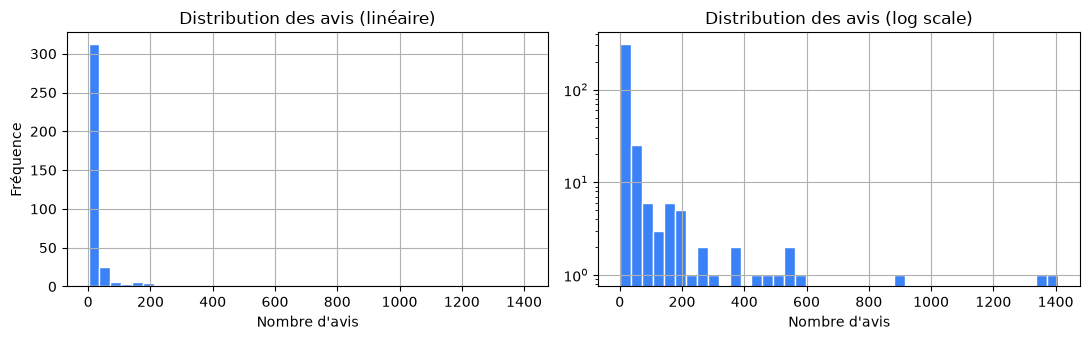

In [13]:
df["reviews_count"] = pd.to_numeric(df["reviews_count"], errors="coerce").fillna(0).astype(int)

print(df["reviews_count"].describe().round(1))
print(f"\nRestaurants SANS aucun avis : {(df['reviews_count'] == 0).sum()}")

# Distribution (log-scale pour voir la longue traîne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

df[df["reviews_count"] > 0]["reviews_count"].hist(bins=40, ax=ax1, color="#3B82F6", edgecolor="white")
ax1.set_title("Distribution des avis (linéaire)")
ax1.set_xlabel("Nombre d'avis"); ax1.set_ylabel("Fréquence")

df[df["reviews_count"] > 0]["reviews_count"].hist(bins=40, ax=ax2, color="#3B82F6", edgecolor="white", log=True)
ax2.set_title("Distribution des avis (log scale)")
ax2.set_xlabel("Nombre d'avis")

plt.tight_layout()
plt.savefig("../data/processed/reviews_distribution.png", dpi=120)
plt.show()


### 5.3 `category` — Catégorie d'établissement
Standardisation : consolidation des variantes orthographiques.


In [14]:
print("Catégories brutes :")
print(df["category"].value_counts().to_string())


Catégories brutes :
category
Restaurant                                        315
Restauration rapide                                51
Restaurant africain                                18
Restaurant de grillades                             8
Café                                                7
Pizzeria                                            6
Restaurant servant le petit-déjeuner                6
Café et restaurant de grillades                     5
Restaurant de spécialités d'Afrique de l'Ouest      4
Restaurant halal                                    4
Magasin vendant du poulet                           4
Restaurant familial                                 4
Restaurant indien                                   3
Boulangerie                                         2
Restaurant diététique                               2
Restaurant français                                 2
Restaurant gastronomique                            2
Restaurant de viande grillée (yakiniku)             2

In [15]:
# Table de mapping → catégories normalisées
CATEGORY_MAP = {
    "Restaurant":                                    "Restaurant",
    "Restauration rapide":                           "Fast food",
    "Restaurant de type buffet":                     "Restaurant",
    "Restaurant africain":                           "Restaurant africain",
    "Restaurant halal":                              "Restaurant halal",
    "Restaurant indien":                             "Restaurant indien",
    "Restaurant italien":                            "Restaurant",
    "Restaurant marocain":                           "Restaurant",
    "Restaurant turc":                               "Restaurant turc",
    "Restaurant libanais":                           "Restaurant",
    "Restaurant mexicain":                           "Restaurant",
    "Restaurant indonésien":                         "Restaurant",
    "Restaurant de grillades":                       "Grillades / BBQ",
    "Restaurant servant des abats au barbecue":      "Grillades / BBQ",
    "Café et restaurant de grillades":               "Café / Lounge",
    "Café":                                          "Café / Lounge",
    "Boulangerie":                                   "Boulangerie / Pâtisserie",
    "Pizzeria":                                      "Pizzeria",
    "Kebab":                                         "Kebab",
    "Sandwicherie":                                  "Sandwich",
    "Restauration rapide":                           "Fast food",
    "Snack":                                         "Fast food",
    "Saladerie":                                     "Fast food",
    "Restaurant de spécialités d'Afrique de l'Ouest": "Restaurant africain",
    "Restaurant diététique":                         "Restaurant",
    "Restaurant végétalien":                         "Restaurant",
    "Restaurant gastronomique":                      "Restaurant",
    "Restaurant familial":                           "Restaurant",
    "Restaurant de fruits de mer":                   "Grillades / BBQ",
    "Restaurant servant le petit-déjeuner":          "Café / Lounge",
    "Bar-restaurant à huîtres":                      "Bar",
    "Bar":                                           "Bar",
    "Café des arts":                                 "Café / Lounge",
    "Cuisine française moderne":                     "Restaurant",
    "Parc de loisirs":                               "Autre",
    "Hôtel":                                         "Hôtel",
    "Magasin vendant du poulet":                     "Fast food",
    "Pizzas à emporter":                             "Pizzeria",
    "Tiffin center":                                 "Fast food",
    "Épicerie":                                      "Autre",
    "Vente de légumes en gros":                      "Autre",
}

df["category_clean"] = df["category"].map(CATEGORY_MAP).fillna("Autre")

print("\nCatégories nettoyées :")
print(df["category_clean"].value_counts().to_string())



Catégories nettoyées :
category_clean
Restaurant                  332
Fast food                    58
Autre                        25
Restaurant africain          22
Café / Lounge                19
Grillades / BBQ              10
Pizzeria                      7
Restaurant halal              4
Restaurant indien             3
Boulangerie / Pâtisserie      2
Bar                           2
Kebab                         2
Sandwich                      2
Hôtel                         1
Restaurant turc               1


### 5.4 `phone` — Numéro de téléphone

In [16]:
# Flag has_phone (présence uniquement — on ne valide pas le format)
df["has_phone"] = df["phone"].notna() & (df["phone"].str.strip() != "")

# Nettoyage basique : supprimer les espaces superflus
df["phone"] = df["phone"].str.strip()

print(f"Avec téléphone    : {df['has_phone'].sum()} ({df['has_phone'].mean():.0%})")
print(f"Sans téléphone    : {(~df['has_phone']).sum()}")

# Vérification format Niger (+227)
niger_fmt = df["phone"].dropna().str.match(r"^\+227")
print(f"Format +227 Niger : {niger_fmt.sum()} / {df['has_phone'].sum()}")


Avec téléphone    : 317 (65%)
Sans téléphone    : 173
Format +227 Niger : 317 / 317


### 5.5 `street` — Adresse
Les adresses encodées en **Google Plus Code** (ex. `G476+RX4`) ne sont pas
exploitables textuellement. On les détecte et on flag séparément.


In [17]:
# Regex Google Plus Code : 4+ caractères alphanumériques + "+" + 2+ caractères
PLUS_CODE_RE = re.compile(r"^[A-Z0-9]{4,}\+[A-Z0-9]{2,}", re.IGNORECASE)

df["is_plus_code"] = (
    df["street"].notna() &
    df["street"].str.strip().str.match(PLUS_CODE_RE)
)
df["has_address"] = df["street"].notna() & (df["street"].str.strip() != "")

n_total    = len(df)
n_pluscode = df["is_plus_code"].sum()
n_text     = (df["has_address"] & ~df["is_plus_code"]).sum()
n_missing  = (~df["has_address"]).sum()

print(f"Adresse textuelle réelle : {n_text:3d} ({n_text/n_total:.0%})")
print(f"Adresse Plus Code seule  : {n_pluscode:3d} ({n_pluscode/n_total:.0%})")
print(f"Adresse manquante        : {n_missing:3d} ({n_missing/n_total:.0%})")
print()
print("Exemple Plus Codes :")
print(df[df["is_plus_code"]][["name","street"]].head(4).to_string(index=False))


Adresse textuelle réelle : 101 (21%)
Adresse Plus Code seule  : 331 (68%)
Adresse manquante        :  58 (12%)

Exemple Plus Codes :
                                                    name                     street
                                                Amandine                   G476+RX4
                                Bab Salam Maurice Delens                   G3MW+WR4
                                                   Rawda G4H4+8R9, Bd du Zarmaganda
Le Moulin Restaurant Boulangerie Pâtisserie Alimentation              H325+Q44, RN1


### 5.6 `website` — Site web

In [18]:
df["has_website"] = df["website"].notna() & (df["website"].str.strip() != "")

# Vérification basique de la structure URL
def is_valid_url(url) -> bool:
    if pd.isna(url): return False
    return bool(re.match(r"https?://[^\s]+", str(url).strip()))

df["website_valid"] = df["website"].apply(is_valid_url)

print(f"Avec site web         : {df['has_website'].sum()} ({df['has_website'].mean():.0%})")
print(f"URL bien formée       : {df['website_valid'].sum()}")
print(f"Sans site web         : {(~df['has_website']).sum()} ({(~df['has_website']).mean():.0%})")

# Domaines les plus fréquents chez ceux qui ont un site
df_web = df[df["has_website"]].copy()
df_web["domain"] = df_web["website"].str.extract(r"https?://(?:www\.)?([^/]+)")
print("\nTop domaines :")
print(df_web["domain"].value_counts().head(10).to_string())


Avec site web         : 26 (5%)
URL bien formée       : 26
Sans site web         : 464 (95%)

Top domaines :
domain
facebook.com              8
radissonhotels.com        3
braviahotels.com          2
cote-jardin-niamey.com    1
otacos.com                1
hunkarniamey.com          1
laggourmandise.com        1
restaurantmumbai.net      1
instagram.com             1
laysa.wegic.app           1


## 6 · Feature Engineering

### 6.1 Score bayésien
La note brute favorise les restaurants avec peu d'avis (biais 5★ / 1 avis).
Le **Bayesian Average** ramène les nouveaux établissements vers la moyenne globale,
proportionnellement à leur manque de données — c'est la méthode utilisée par IMDb.

$$\text{score\_bayes} = \frac{C \cdot m + n \cdot s}{C + n}$$

- $m$ = note moyenne globale
- $C$ = nombre d'avis moyen global (prior)
- $n$ = nombre d'avis du restaurant
- $s$ = note brute du restaurant


In [19]:
# Bayesian Average
valid = df[df["score_raw"].notna() & (df["reviews_count"] > 0)].copy()

m = valid["score_raw"].mean()            # note moyenne globale
C = valid["reviews_count"].mean()        # prior = nb d'avis moyen

df["score_bayes"] = np.where(
    df["score_raw"].notna() & (df["reviews_count"] > 0),
    (C * m + df["reviews_count"] * df["score_raw"]) / (C + df["reviews_count"]),
    np.nan
)
df["score_bayes"] = df["score_bayes"].round(3)

print(f"Prior (C = nb moyen d'avis) : {C:.1f}")
print(f"Prior (m = note globale)    : {m:.3f}")
print()

# Comparaison top-10 brut vs bayésien
comparison = (
    df[df["reviews_count"] >= 10]
    [["name", "score_raw", "reviews_count", "score_bayes"]]
    .sort_values("score_bayes", ascending=False)
    .head(10)
)
print("Top 10 par score bayésien (min. 10 avis) :")
print(comparison.to_string(index=False))


Prior (C = nb moyen d'avis) : 39.3
Prior (m = note globale)    : 4.106

Top 10 par score bayésien (min. 10 avis) :
                         name  score_raw  reviews_count  score_bayes
           Restaurant Al-Mina        4.9            443        4.835
              Zaxi Restaurant        4.7            167        4.587
    New York Restaurant & Bar        4.6            488        4.563
                    Fofo Taco        4.8             32        4.417
                  Burger time        4.7             35        4.386
                  CASA D LUCA        4.8             24        4.369
         Hamza Food and Juice        5.0             13        4.328
La Grande Gourmandise (La GG)        4.4             63        4.287
                  Côté Jardin        4.3            557        4.287
                  Nama Lounge        4.5             31        4.280


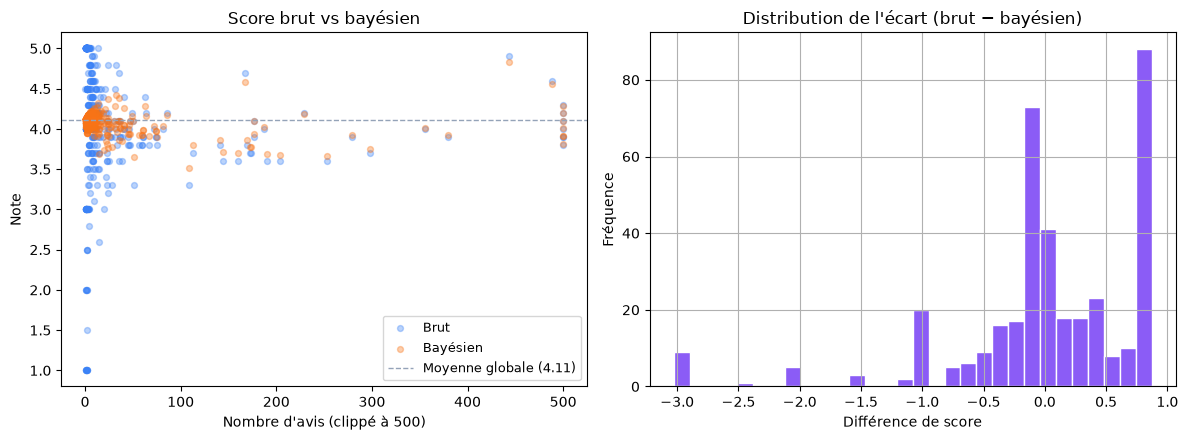

Écart moyen |brut - bayésien| : 0.540 points


In [20]:
# Visualisation : impact du score bayésien
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.scatter(
    df["reviews_count"].clip(upper=500),
    df["score_raw"],
    alpha=0.35, s=18, color="#3B82F6", label="Brut"
)
ax.scatter(
    df["reviews_count"].clip(upper=500),
    df["score_bayes"],
    alpha=0.35, s=18, color="#F97316", label="Bayésien"
)
ax.axhline(m, ls="--", color="#94A3B8", lw=1, label=f"Moyenne globale ({m:.2f})")
ax.set_xlabel("Nombre d'avis (clippé à 500)")
ax.set_ylabel("Note")
ax.set_title("Score brut vs bayésien")
ax.legend(fontsize=9)

ax = axes[1]
diff = (df["score_raw"] - df["score_bayes"]).dropna()
diff.hist(bins=30, color="#8B5CF6", edgecolor="white", ax=ax)
ax.set_title("Distribution de l'écart (brut − bayésien)")
ax.set_xlabel("Différence de score")
ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.savefig("../data/processed/bayesian_impact.png", dpi=120)
plt.show()
print(f"Écart moyen |brut - bayésien| : {diff.abs().mean():.3f} points")


### 6.2 `reliability_tier` — Niveau de fiabilité statistique
Segmentation basée sur le volume d'avis pour contextualiser les analyses.


In [21]:
def reliability_tier(n: int) -> str:
    if n == 0:    return "0_no_reviews"
    if n < 5:     return "1_very_low"
    if n < 20:    return "2_low"
    if n < 50:    return "3_medium"
    if n < 200:   return "4_high"
    return        "5_very_high"

df["reliability_tier"] = df["reviews_count"].apply(reliability_tier)

tier_stats = (
    df.groupby("reliability_tier")
      .agg(
          nb_restaurants=("name", "count"),
          pct=("name", lambda x: f"{len(x)/len(df)*100:.1f}%"),
          score_moyen=("score_bayes", "mean"),
      )
      .round(3)
)
print(tier_stats.to_string())


                  nb_restaurants    pct  score_moyen
reliability_tier                                    
0_no_reviews                 118  24.1%          NaN
1_very_low                   180  36.7%        4.107
2_low                        102  20.8%        4.115
3_medium                      45   9.2%        4.039
4_high                        29   5.9%        3.940
5_very_high                   16   3.3%        4.047


### 6.3 Flags de qualité de présence en ligne

In [22]:
# Score de complétude de la fiche Google (0–4)
df["completeness_score"] = (
    df["has_phone"].astype(int) +
    df["has_address"].astype(int) +
    df["has_website"].astype(int) +
    df["score_raw"].notna().astype(int)
)

print("Distribution du score de complétude :")
print(df["completeness_score"].value_counts().sort_index().to_string())


Distribution du score de complétude :
completeness_score
0      3
1     80
2    174
3    212
4     21


## 7 · Rapport qualité final
Synthèse des transformations appliquées et état du dataset propre.


In [23]:
def quality_report(df: pd.DataFrame) -> None:
    print("=" * 55)
    print("RAPPORT QUALITÉ — Dataset Restaurants Niamey")
    print("=" * 55)
    print(f"  Lignes totales        : {len(df)}")
    print(f"  Colonnes totales      : {len(df.columns)}")
    print()
    print("COMPLÉTUDE")
    for col in ["score_raw", "score_bayes", "reviews_count", "phone",
                "street", "website", "category_clean"]:
        if col in df.columns:
            n_ok = df[col].notna().sum()
            print(f"  {col:<22}: {n_ok:3d} / {len(df)} ({n_ok/len(df)*100:.0f}%)")
    print()
    print("DISTRIBUTION DES AVIS")
    rc = df["reviews_count"]
    print(f"  Médiane       : {rc.median():.0f}")
    print(f"  Moyenne       : {rc.mean():.1f}")
    print(f"  Max           : {rc.max()}")
    print(f"  0 avis        : {(rc == 0).sum()}")
    print(f"  ≥ 20 avis     : {(rc >= 20).sum()} (seuil analyse fiable)")
    print()
    print("FIABILITÉ")
    print(df["reliability_tier"].value_counts().sort_index().to_string())
    print()
    print("CHAÎNES DÉTECTÉES")
    print(f"  Restaurants en chaîne : {df['is_chain'].sum()}")
    print("=" * 55)

quality_report(df)


RAPPORT QUALITÉ — Dataset Restaurants Niamey
  Lignes totales        : 490
  Colonnes totales      : 21

COMPLÉTUDE
  score_raw             : 373 / 490 (76%)
  score_bayes           : 372 / 490 (76%)
  reviews_count         : 490 / 490 (100%)
  phone                 : 317 / 490 (65%)
  street                : 432 / 490 (88%)
  website               :  26 / 490 (5%)
  category_clean        : 490 / 490 (100%)

DISTRIBUTION DES AVIS
  Médiane       : 2
  Moyenne       : 29.8
  Max           : 1408
  0 avis        : 118
  ≥ 20 avis     : 90 (seuil analyse fiable)

FIABILITÉ
reliability_tier
0_no_reviews    118
1_very_low      180
2_low           102
3_medium         45
4_high           29
5_very_high      16

CHAÎNES DÉTECTÉES
  Restaurants en chaîne : 6


## 8 · Export
On exporte le dataset propre avec toutes les colonnes dérivées.
Le dataset brut d'origine est conservé intact dans `data/raw/`.


In [24]:
# Colonnes finales ordonnées
FINAL_COLS = [
    # Identité
    "name", "category", "category_clean", "is_chain",
    # Localisation
    "street", "city", "state", "country_code",
    "has_address", "is_plus_code",
    # Contact & présence web
    "phone", "has_phone", "website", "has_website", "website_valid",
    # Notes
    "score_raw", "reviews_count", "score_bayes",
    "reliability_tier", "completeness_score",
    # Source
    "maps_url",
]

df_clean = df[[c for c in FINAL_COLS if c in df.columns]].copy()
df_clean.to_csv(PROC_PATH, index=False, encoding="utf-8-sig")

print(f"✅ Dataset exporté : {PROC_PATH}")
print(f"   Shape : {df_clean.shape}")
print(f"   Taille : {PROC_PATH.stat().st_size / 1024:.1f} Ko")
print()
print("Aperçu des 5 premières lignes :")
df_clean.head()


✅ Dataset exporté : ../data/processed/restaurants_clean.csv
   Shape : (490, 21)
   Taille : 123.1 Ko

Aperçu des 5 premières lignes :


,name,category,category_clean,is_chain,street,city,state,country_code,has_address,is_plus_code,phone,has_phone,website,has_website,website_valid,score_raw,reviews_count,score_bayes,reliability_tier,completeness_score,maps_url
0,Amandine,Restaurant,Restaurant,False,G476+RX4,Niamey,NaN,NE,True,True,+227 90 19 49 08,True,https://www.facebook.com/restoamandine?mibextid=kFxxJD,True,True,3.9,1408,3.906,5_very_high,4,https://www.google.com/maps/search/?api=1&query=Amandine...
1,Bab Salam Maurice Delens,Restauration rapide,Fast food,False,G3MW+WR4,Niamey,NaN,NE,True,True,+227 91 95 47 48,True,NaN,False,False,3.9,1351,3.906,5_very_high,3,https://www.google.com/maps/search/?api=1&query=Bab%20Sa...
2,Rawda,Restaurant,Restaurant,False,"G4H4+8R9, Bd du Zarmaganda",Niamey,NaN,NE,True,True,+227 88 66 80 20,True,NaN,False,False,3.8,883,3.813,5_very_high,3,https://www.google.com/maps/search/?api=1&query=Rawda&qu...
3,Le Moulin Restaurant Boulangerie Pâtisserie Alimentation,Restaurant,Restaurant,False,"H325+Q44, RN1",Niamey,NaN,NE,True,True,+227 82 94 94 75,True,NaN,False,False,4.0,580,4.007,5_very_high,3,https://www.google.com/maps/search/?api=1&query=Le%20Mou...
4,RESTAURANT LE PILIER,Restaurant italien,Restaurant,False,rue de la tapoa,Niamey,NaN,NE,True,False,+227 77 83 82 82,True,NaN,False,False,4.2,559,4.194,5_very_high,3,https://www.google.com/maps/search/?api=1&query=RESTAURA...


In [25]:
import os
from pathlib import Path

# Redéfinition locale par sécurité si la session a été réinitialisée
CHECK_RAW = Path("../data/raw/All_Niamey_Restaurants.csv")
CHECK_PROC = Path("../data/processed/restaurants_clean.csv")

def verify_paths(raw, proc):
    print(f"--- Vérification des Chemins ---")
    paths_to_check = {
        "Fichier Brut": raw,
        "Fichier Nettoyé": proc,
        "Dossier Raw": raw.parent,
        "Dossier Proc": proc.parent
    }

    for label, path in paths_to_check.items():
        status = "✅ Existe" if path.exists() else "❌ Introuvable"
        print(f"{label:<15} : {path} ({status})")

    if raw.parent.exists():
        print(f"\nContenu de {raw.parent} :")
        print([f.name for f in raw.parent.iterdir()])

verify_paths(CHECK_RAW, CHECK_PROC)

--- Vérification des Chemins ---
Fichier Brut    : ../data/raw/All_Niamey_Restaurants.csv (✅ Existe)
Fichier Nettoyé : ../data/processed/restaurants_clean.csv (✅ Existe)
Dossier Raw     : ../data/raw (✅ Existe)
Dossier Proc    : ../data/processed (✅ Existe)

Contenu de ../data/raw :
['All_Niamey_Restaurants.csv']


---
## ✅ Résumé des transformations

| Étape | Action |
|---|---|
| Schéma | Renommage snake_case, suppression colonne parasite |
| Valeurs manquantes | Audit complet, suppression des lignes sans nom |
| Doublons | Déduplication sur `maps_url`, flag `is_chain` |
| `score_raw` | Conversion float, nullification des 0 |
| `reviews_count` | Conversion int, imputation 0 pour NaN |
| `category` | Consolidation en 10 catégories normalisées |
| `phone` | Flag `has_phone` |
| `street` | Flag `has_address`, détection `is_plus_code` |
| `website` | Flag `has_website`, validation format URL |
| **Feature : `score_bayes`** | Bayesian Average (biais petits échantillons corrigé) |
| **Feature : `reliability_tier`** | 6 niveaux de fiabilité selon le volume d'avis |
| **Feature : `completeness_score`** | Score 0–4 de complétude de la fiche |

**Prochain notebook :** `02_eda.ipynb` — Analyse exploratoire complète
